# Crack Segmentation with U-Net (PyTorch)

This notebook implements an improved U-Net for crack segmentation using **PyTorch**.

**Key improvements over the previous TensorFlow version:**
- Deeper U-Net (4 encoder levels instead of 3)
- Increased filter counts: 64 → 128 → 256 → 512 (vs 16 → 32 → 64 → 128)
- `ConvTranspose2d` for upsampling instead of `UpSampling2D` (learnable)
- Richer data augmentation (rotations, brightness, contrast)
- Combined `BCE + Dice` loss with focal weighting
- `AdamW` optimizer with cosine annealing LR scheduler
- Early stopping & model checkpointing
- Dataset loaded directly from ZIP (no extraction needed)
- Detailed metrics: IoU, Dice, Precision, Recall, F1

**Dataset:** [Crack Segmentation Dataset](https://www.kaggle.com/datasets/lakshaymiddha/crack-segmentation-dataset)

Structure expected in zip:
```
crack_segmentation_dataset.zip
├── train/
│   ├── images/
│   └── masks/
└── test/
    ├── images/
    └── masks/
```

## 1. Setup & Imports

In [ ]:
# !pip install torch torchvision albumentations opencv-python-headless

In [ ]:
import os
import io
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ─── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

## 2. Configuration

In [ ]:
# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMAGE_SIZE    = 256         # Input resolution (H x W)
BATCH_SIZE    = 8          # Reduced from 64 for better gradient estimates
NUM_EPOCHS    = 60
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4        # AdamW regularization
NUM_WORKERS   = 2
PIN_MEMORY    = True if torch.cuda.is_available() else False

# Paths
ZIP_PATH      = r"PATH\TO\crack-segmentation-dataset.zip"  # adjust if needed
EXTRACT_DIR = r"PATH\TO\extract\folder"
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)
print(f"Extracted to: {EXTRACT_DIR}")
CHECKPOINT    = "best_crack_model_pytorch.pth"

# Early stopping
PATIENCE      = 10          # Stop if val IoU doesn't improve for N epochs

## 3. Dataset

In [3]:
class CrackDataset(Dataset):
    """Reads directly from extracted folders — fast disk I/O, no ZIP overhead."""

    def __init__(self, root_dir: str, split: str = "train", transform=None):
        self.transform = transform

        img_dir  = os.path.join(root_dir, "crack_segmentation_dataset", split, "images")
        mask_dir = os.path.join(root_dir, "crack_segmentation_dataset", split, "masks")

        exts = (".jpg", ".jpeg", ".png")
        self.image_files = sorted([
            os.path.join(img_dir, f) for f in os.listdir(img_dir)
            if f.lower().endswith(exts)
        ])
        self.mask_files = sorted([
            os.path.join(mask_dir, f) for f in os.listdir(mask_dir)
            if f.lower().endswith(exts)
        ])

        assert len(self.image_files) == len(self.mask_files), (
            f"Mismatch: {len(self.image_files)} images vs {len(self.mask_files)} masks"
        )
        print(f"[{split}] {len(self.image_files)} pairs found.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img  = np.array(Image.open(self.image_files[idx]).convert("RGB"),  dtype=np.uint8)
        mask = np.array(Image.open(self.mask_files[idx]).convert("L"),      dtype=np.uint8)
        mask = (mask > 127).astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented["image"]
            mask = augmented["mask"].float().unsqueeze(0)

        return img, mask

In [ ]:
# ─── Augmentation Pipelines ───────────────────────────────────────────────────

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate=(-15, 15), p=0.5),

    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(noise_scale_factor=0.1, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
   
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# ─── DataLoaders ──────────────────────────────────────────────────────────────
EXTRACT_DIR = r"C:\Users\silaa\OneDrive\Desktop\crack_segmentation"
train_dataset = CrackDataset(EXTRACT_DIR, split="train", transform=train_transform)
val_dataset   = CrackDataset(EXTRACT_DIR, split="test",  transform=val_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0,
    pin_memory=PIN_MEMORY, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0,
    pin_memory=PIN_MEMORY
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

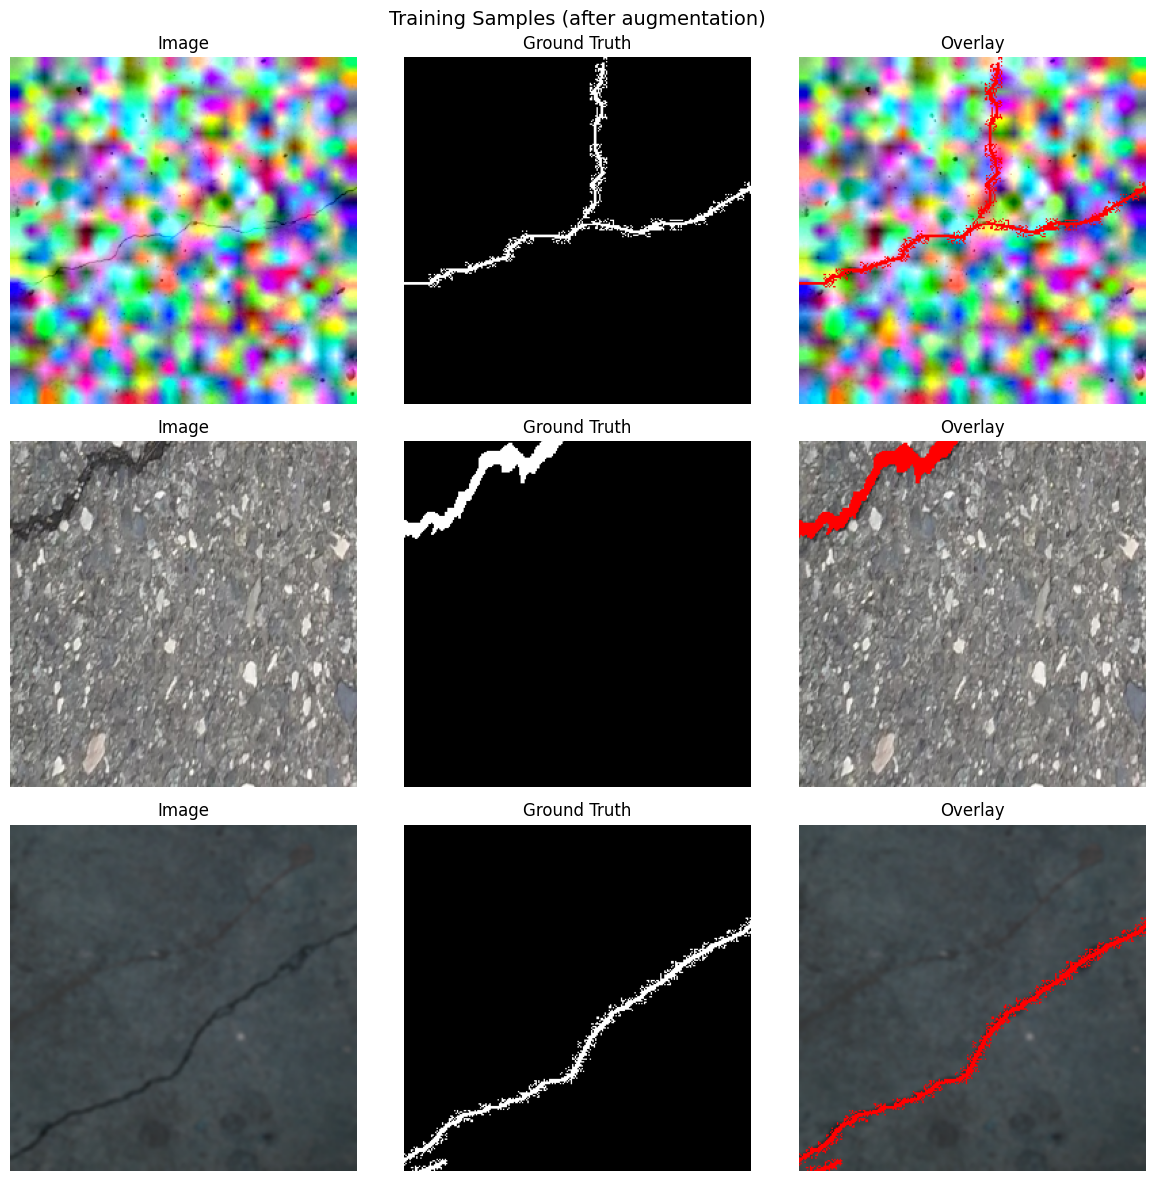

In [5]:
# ─── Visualize Samples ────────────────────────────────────────────────────────
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    """Reverse ImageNet normalization for visualization."""
    img = tensor.permute(1, 2, 0).cpu().numpy()
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)

imgs, masks = next(iter(train_loader))
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    axes[i, 0].imshow(denormalize(imgs[i]))
    axes[i, 0].set_title("Image");       axes[i, 0].axis("off")
    axes[i, 1].imshow(masks[i].squeeze().numpy(), cmap="gray")
    axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis("off")
    overlay = denormalize(imgs[i]).copy()
    m = masks[i].squeeze().numpy()
    overlay[m == 1] = [1, 0, 0]   # highlight crack pixels in red
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Overlay"); axes[i, 2].axis("off")
plt.suptitle("Training Samples (after augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. U-Net Architecture

The improved U-Net has:
- **4 encoder levels** (vs 3 in the TF version)
- **Larger filter base** starting at 64 (vs 16 before)
- **Learnable upsampling** via `ConvTranspose2d` (vs `UpSampling2D`)
- **Dropout** in the bottleneck to reduce overfitting

In [6]:
class ConvBlock(nn.Module):
    """Double Conv → BN → ReLU block (standard U-Net building block)."""

    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(p=dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    """Learnable upsampling via ConvTranspose2d followed by a ConvBlock."""

    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Align spatial dimensions in case of odd sizes
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """
    4-level U-Net for binary crack segmentation.

    Filter progression:
        Encoder:    64 → 128 → 256 → 512
        Bottleneck: 1024
        Decoder:    512 → 256 → 128 → 64
    """

    def __init__(self, in_channels: int = 3, base_filters: int = 64):
        super().__init__()
        f = base_filters   # shorthand

        # ── Encoder ───────────────────────────────────────────────────────────
        self.enc1 = ConvBlock(in_channels, f)
        self.enc2 = ConvBlock(f,     f * 2)
        self.enc3 = ConvBlock(f * 2, f * 4)
        self.enc4 = ConvBlock(f * 4, f * 8)
        self.pool = nn.MaxPool2d(2)

        # ── Bottleneck ────────────────────────────────────────────────────────
        self.bottleneck = ConvBlock(f * 8, f * 16, dropout=0.3)

        # ── Decoder ───────────────────────────────────────────────────────────
        self.dec4 = UpBlock(f * 16, f * 8,  f * 8)
        self.dec3 = UpBlock(f * 8,  f * 4,  f * 4)
        self.dec2 = UpBlock(f * 4,  f * 2,  f * 2)
        self.dec1 = UpBlock(f * 2,  f,      f)

        # ── Output (1×1 conv → sigmoid) ───────────────────────────────────────
        self.out_conv = nn.Conv2d(f, 1, kernel_size=1)

    def forward(self, x):
        # Encoder path
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))

        # Bottleneck
        b  = self.bottleneck(self.pool(s4))

        # Decoder path (skip connections)
        x  = self.dec4(b,  s4)
        x  = self.dec3(x,  s3)
        x  = self.dec2(x,  s2)
        x  = self.dec1(x,  s1)

        return self.out_conv(x)   


# ─── Sanity Check ─────────────────────────────────────────────────────────────
model = UNet(in_channels=3, base_filters=64).to(DEVICE)
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
out   = model(dummy)
print(f"Input shape : {dummy.shape}")
print(f"Output shape: {out.shape}")

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Input shape : torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])
Total params    : 31,037,633
Trainable params: 31,037,633


In [7]:
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train batches: 1200
Val batches:   212


## 5. Loss Functions & Metrics

In [9]:
# ─── Dice Loss ────────────────────────────────────────────────────────────────
def dice_loss(pred: torch.Tensor, target: torch.Tensor, smooth: float = 1.0) -> torch.Tensor:
    """
    Soft Dice loss — directly optimizes the Dice coefficient.
    Handles class imbalance well (cracks are typically sparse).
    """
    pred   = torch.sigmoid(pred)  
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1.0 - (2.0 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


# ─── BCE + Dice Combined Loss ─────────────────────────────────────────────────
def bce_dice_loss(
    pred: torch.Tensor,
    target: torch.Tensor,
    bce_weight: float = 0.3
) -> torch.Tensor:
    """
    Combined loss:
        L = bce_weight * BCE + (1 - bce_weight) * Dice

    BCE gives pixel-wise gradient signal; Dice handles class imbalance.
    Using pos_weight upweights the crack class to fight background dominance.
    """
    pos_weight = torch.tensor([10.0]).to(pred.device)  
    bce = F.binary_cross_entropy_with_logits(pred, target, pos_weight=pos_weight, reduction="mean")
    dc  = dice_loss(pred, target)
    return bce_weight * bce + (1.0 - bce_weight) * dc


# ─── Metrics ──────────────────────────────────────────────────────────────────
@torch.no_grad()
def compute_metrics(
    pred: torch.Tensor,
    target: torch.Tensor,
    threshold: float = 0.5
) -> dict:
    """
    Returns IoU, Dice, Precision, Recall, F1 for a batch.
    All computed on binarized predictions.
    """
    pred = torch.sigmoid(pred)
    pred_bin = (pred > threshold).float()
    target   = target.float()

    pred_flat   = pred_bin.view(-1)
    target_flat = target.view(-1)

    TP = (pred_flat * target_flat).sum()
    FP = (pred_flat * (1 - target_flat)).sum()
    FN = ((1 - pred_flat) * target_flat).sum()

    eps = 1e-7
    iou       = (TP + eps) / (TP + FP + FN + eps)
    dice      = (2 * TP + eps) / (2 * TP + FP + FN + eps)
    precision = (TP + eps) / (TP + FP + eps)
    recall    = (TP + eps) / (TP + FN + eps)
    f1        = (2 * precision * recall) / (precision + recall + eps)

    return {
        "iou":       iou.item(),
        "dice":      dice.item(),
        "precision": precision.item(),
        "recall":    recall.item(),
        "f1":        f1.item(),
    }

## 6. Training Loop

In [10]:
def train_one_epoch(model, loader, optimizer, scaler, device):
    from tqdm import tqdm
    model.train()
    total_loss = 0.0
    total_metrics = {"iou": 0, "dice": 0, "precision": 0, "recall": 0, "f1": 0}

    for imgs, masks in tqdm(loader, desc=f"Training", leave=False):

        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            preds = model(imgs)                         # [B, 1, H, W]
            loss  = bce_dice_loss(preds, masks)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        m = compute_metrics(preds, masks)
        for k in total_metrics:
            total_metrics[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in total_metrics.items()}


@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_metrics = {"iou": 0, "dice": 0, "precision": 0, "recall": 0, "f1": 0}

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss  = bce_dice_loss(preds, masks)

        total_loss += loss.item()
        m = compute_metrics(preds, masks)
        for k in total_metrics:
            total_metrics[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in total_metrics.items()}

In [ ]:
# ─── Optimizer & Scheduler ────────────────────────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)
scaler = torch.amp.GradScaler("cuda")
# ─── History ──────────────────────────────────────────────────────────────────
history = {
    "train_loss": [], "val_loss": [],
    "train_iou":  [], "val_iou":  [],
    "train_dice": [], "val_dice": [],
}

best_val_iou   = 0.0
patience_count = 0

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train IoU':>9} | {'Val Loss':>8} | {'Val IoU':>7} | {'Val Dice':>8} | LR")
print("-" * 78)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_m = train_one_epoch(model, train_loader,  optimizer, scaler, DEVICE)
    val_loss,   val_m   = validate(model, val_loader, DEVICE)
    scheduler.step()

    # Log
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_m["iou"])
    history["val_iou"].append(val_m["iou"])
    history["train_dice"].append(train_m["dice"])
    history["val_dice"].append(val_m["dice"])

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_m['iou']:>9.4f} | "
          f"{val_loss:>8.4f} | {val_m['iou']:>7.4f} | {val_m['dice']:>8.4f} | {current_lr:.2e}")

    # ── Checkpoint: save best model ──────────────────────────────────────────
    if val_m["iou"] > best_val_iou:
        best_val_iou   = val_m["iou"]
        patience_count = 0
        torch.save({
            "epoch":      epoch,
            "model":      model.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "val_iou":    best_val_iou,
        }, CHECKPOINT)
        print(f"  ✓ New best val IoU: {best_val_iou:.4f} — model saved.")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

print(f"\nTraining complete. Best Val IoU: {best_val_iou:.4f}")

## 7. Training Curves

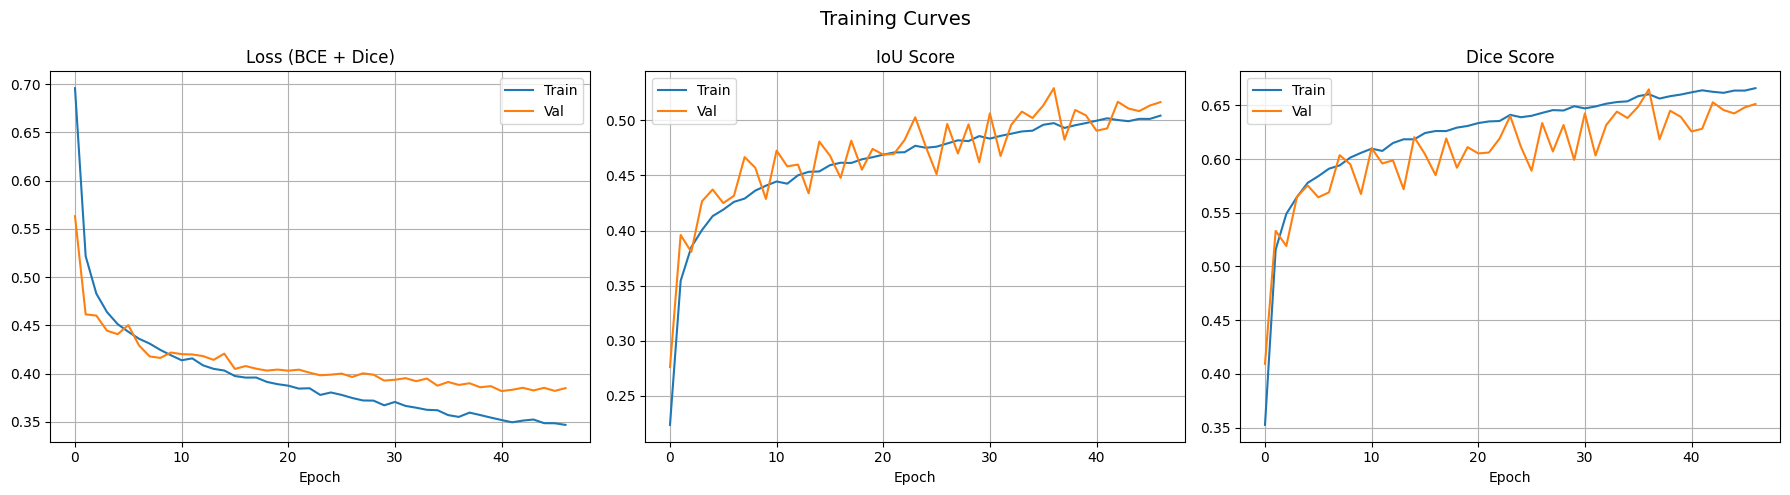

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss (BCE + Dice)"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history["train_iou"], label="Train")
axes[1].plot(history["val_iou"],   label="Val")
axes[1].set_title("IoU Score"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

axes[2].plot(history["train_dice"], label="Train")
axes[2].plot(history["val_dice"],   label="Val")
axes[2].set_title("Dice Score"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(True)

plt.suptitle("Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Evaluation on Test Set

In [13]:
# ─── Load best checkpoint ─────────────────────────────────────────────────────
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
print(f"Loaded best model from epoch {ckpt['epoch']} (val IoU = {ckpt['val_iou']:.4f})")

# ─── Full Test Evaluation ─────────────────────────────────────────────────────
_, test_metrics = validate(model, val_loader, DEVICE)

print("\n===== Test Set Metrics =====")
for k, v in test_metrics.items():
    print(f"  {k.capitalize():>10}: {v:.4f}")

C:\Users\silaa\AppData\Local\Temp\ipykernel_35292\1227002363.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT, map_location=DEVICE)


Loaded best model from epoch 37 (val IoU = 0.5293)

===== Test Set Metrics =====
         Iou: 0.5293
        Dice: 0.6649
   Precision: 0.6040
      Recall: 0.8141
          F1: 0.6649


## 9. Qualitative Results

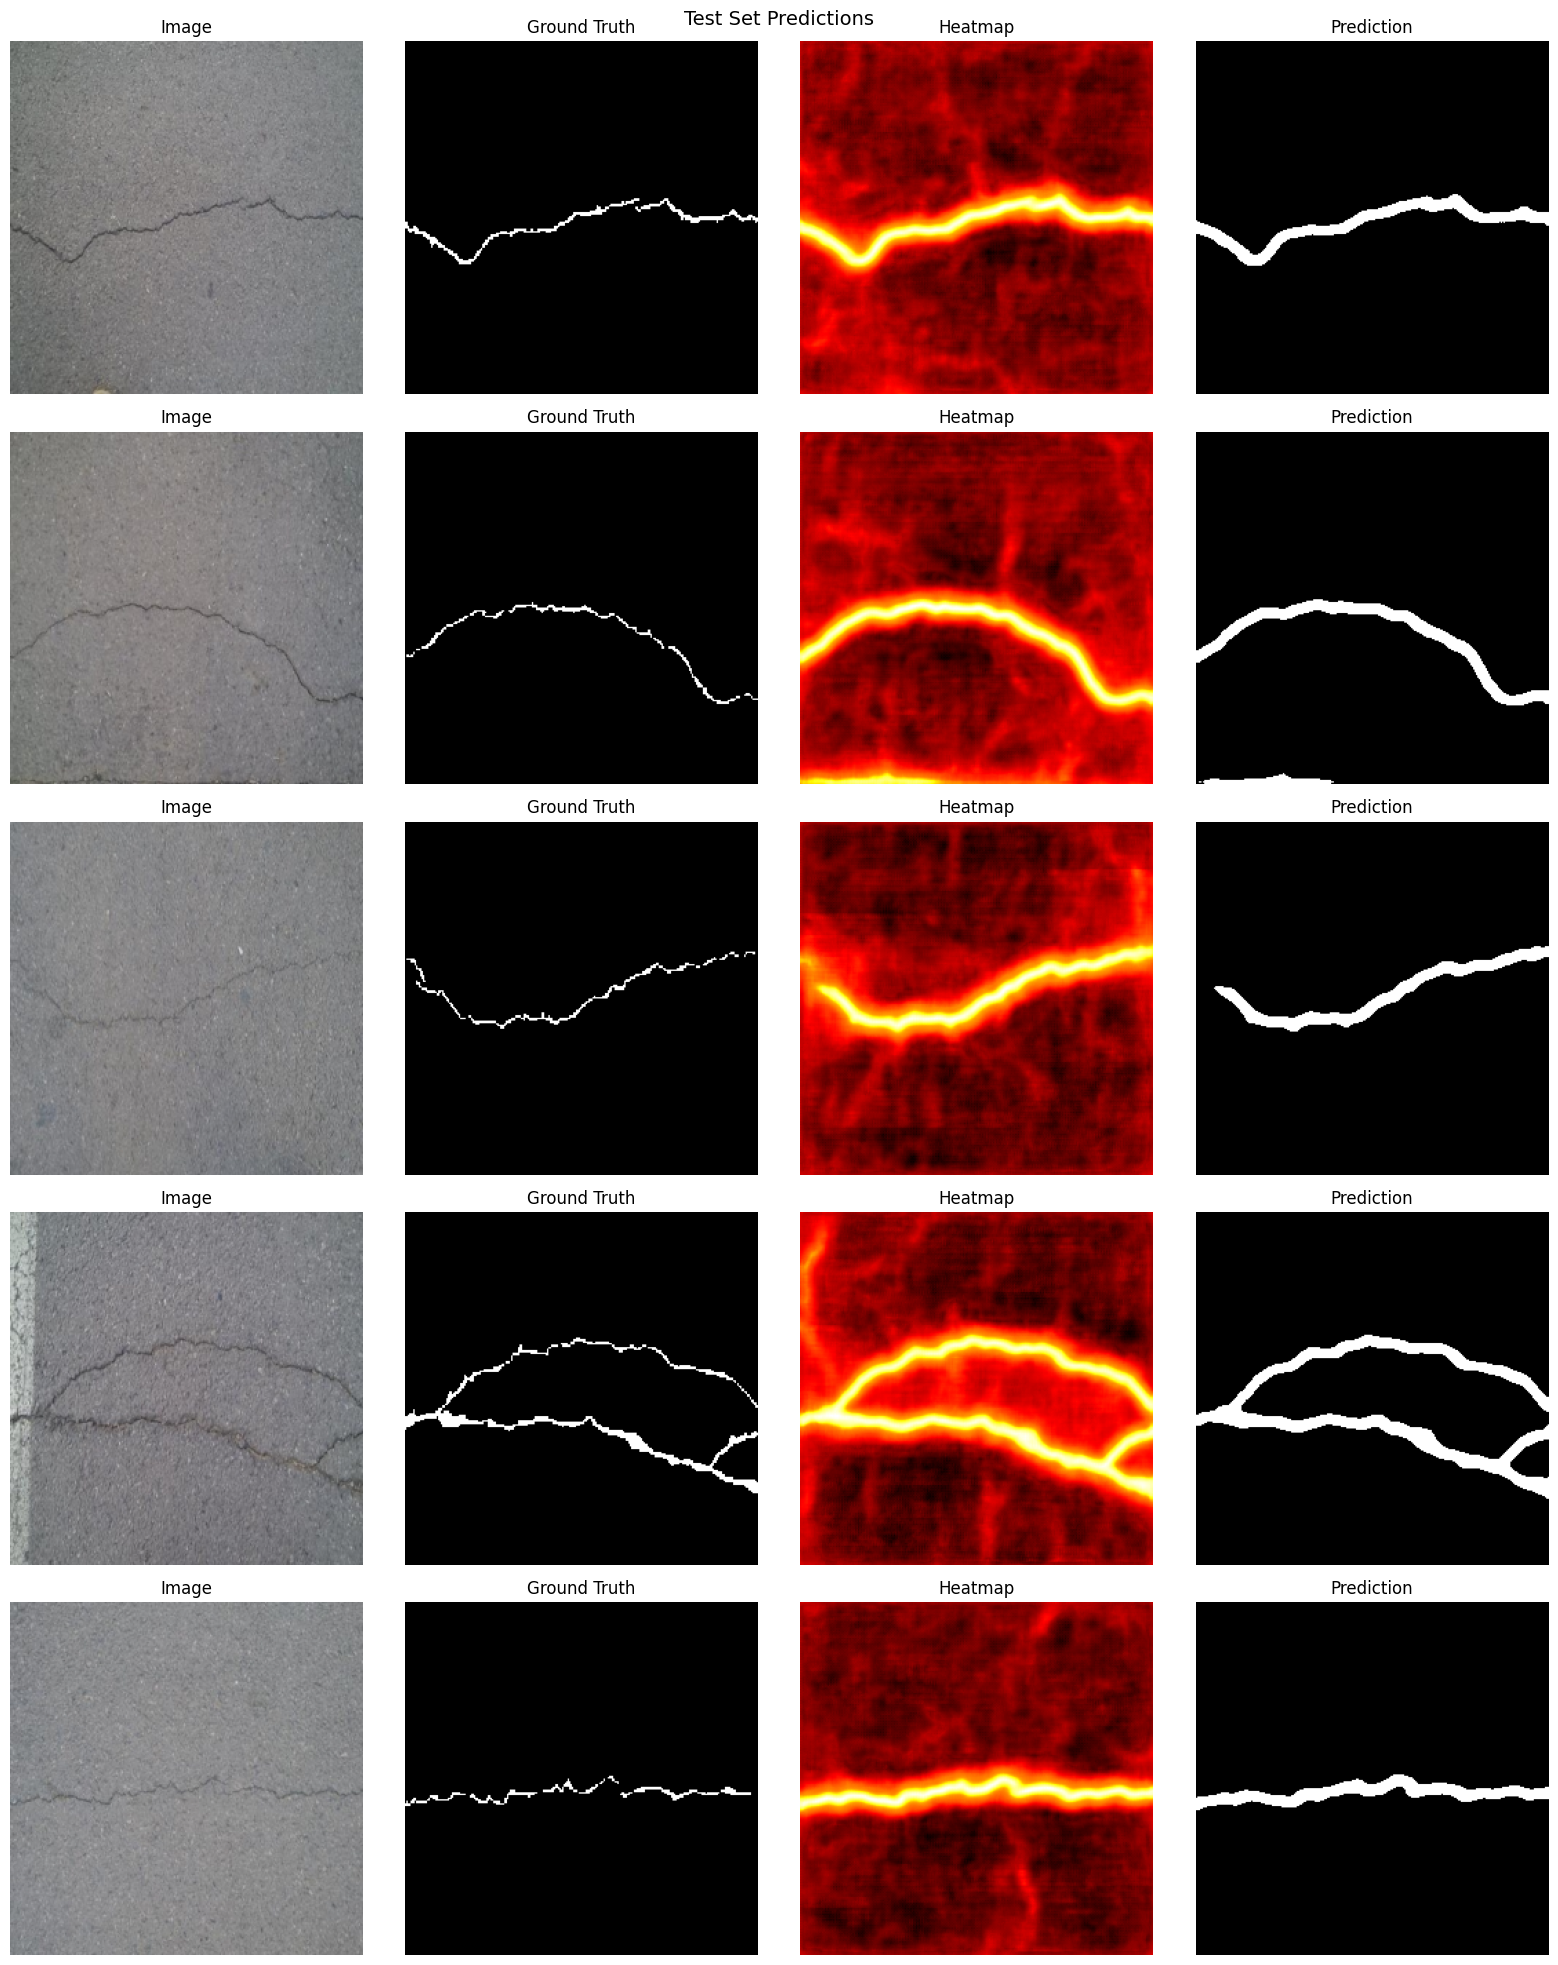

In [14]:
model.eval()
imgs, masks = next(iter(val_loader))

with torch.no_grad():
    preds = model(imgs.to(DEVICE)).cpu()

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
for i in range(5):
    img_np   = denormalize(imgs[i])
    mask_np  = masks[i].squeeze().numpy()
    pred_np  = preds[i].squeeze().numpy()
    pred_bin = (pred_np > 0.5).astype(np.float32)

    axes[i, 0].imshow(img_np);                       axes[i, 0].set_title("Image");         axes[i, 0].axis("off")
    axes[i, 1].imshow(mask_np,  cmap="gray");        axes[i, 1].set_title("Ground Truth");  axes[i, 1].axis("off")
    axes[i, 2].imshow(pred_np,  cmap="hot");         axes[i, 2].set_title("Heatmap");       axes[i, 2].axis("off")
    axes[i, 3].imshow(pred_bin, cmap="gray");        axes[i, 3].set_title("Prediction");    axes[i, 3].axis("off")

plt.suptitle("Test Set Predictions", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Threshold Analysis

Finding the optimal decision threshold on the validation set.

Best threshold by IoU: 0.90 → IoU = 0.5600
Best threshold by F1 : 0.90 → F1  = 0.7179


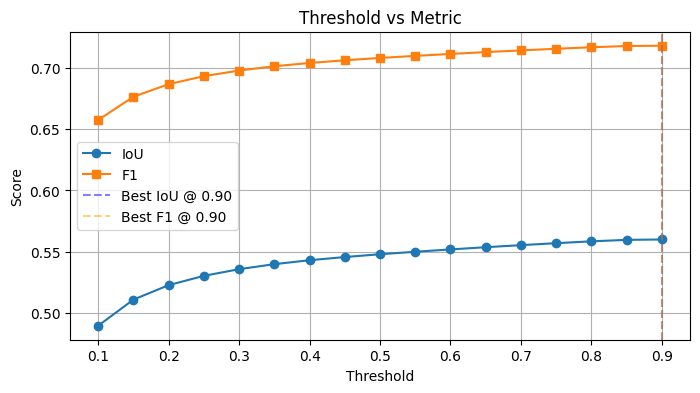

In [15]:
# Collect all predictions and targets
all_preds  = []
all_masks  = []

model.eval()
with torch.no_grad():
    for imgs, masks in val_loader:
        p = model(imgs.to(DEVICE)).cpu()
        all_preds.append(p)
        all_masks.append(masks)

all_preds = torch.cat(all_preds)
all_masks = torch.cat(all_masks)

# Sweep thresholds
thresholds = np.linspace(0.1, 0.9, 17)
iou_scores = []
f1_scores  = []

for t in thresholds:
    m = compute_metrics(all_preds, all_masks, threshold=t)
    iou_scores.append(m["iou"])
    f1_scores.append(m["f1"])

best_t_iou = thresholds[np.argmax(iou_scores)]
best_t_f1  = thresholds[np.argmax(f1_scores)]

print(f"Best threshold by IoU: {best_t_iou:.2f} → IoU = {max(iou_scores):.4f}")
print(f"Best threshold by F1 : {best_t_f1:.2f} → F1  = {max(f1_scores):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, iou_scores, "o-", label="IoU")
plt.plot(thresholds, f1_scores,  "s-", label="F1")
plt.axvline(best_t_iou, linestyle="--", color="blue",  alpha=0.5, label=f"Best IoU @ {best_t_iou:.2f}")
plt.axvline(best_t_f1,  linestyle="--", color="orange", alpha=0.5, label=f"Best F1 @ {best_t_f1:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Threshold vs Metric"); plt.legend(); plt.grid(True)
plt.show()

## 11. Model Export

Export to TorchScript for production deployment.

In [ ]:
model.eval()
scripted = torch.jit.script(model)
scripted.save("crack_unet_scripted.pt")
print("Model exported to crack_unet_scripted.pt")

# Verify
loaded = torch.jit.load("crack_unet_scripted.pt").to(DEVICE)
with torch.no_grad():
    test_in  = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    test_out = loaded(test_in)
print(f"Scripted model output shape: {test_out.shape} ✓")

---

## 12. Possible Improvements & Next Steps

Based on the results of this notebook, here are concrete techniques to further improve performance:

### 🏗️ Architecture
- **Attention U-Net**: Add attention gates on skip connections to suppress non-crack features.
- **ResU-Net**: Replace double-conv blocks with residual blocks to allow deeper networks without vanishing gradients.
- **Encoder transfer learning**: Replace the U-Net encoder with a pretrained backbone (e.g. EfficientNet-B4, ResNet-50 via `segmentation_models_pytorch`). Pretrained features generalize much better from ImageNet.
- **Deeper bottleneck with ASPP**: Use Atrous Spatial Pyramid Pooling in the bottleneck to capture multi-scale context (cracks appear at many scales).
- **Transformer-based decoder**: Experiment with SegFormer or Swin-UNet decoders for global context.

### 📉 Loss Functions
- **Focal Tversky loss**: Combines Tversky index with focal weighting — particularly useful when recall (catching all crack pixels) matters more than precision.
- **Lovász-Softmax**: Directly optimizes IoU, avoiding the proxy issue with BCE/Dice.
- **Boundary loss**: Add a term that penalizes predictions far from the crack boundary — improves thin crack detection.

### 📊 Data
- **More aggressive augmentation**: Add elastic deformations, grid distortions, and CLAHE (contrast-limited histogram equalization) to simulate aged concrete.
- **Mixup / CutMix for segmentation**: Blend images and masks to increase variability.
- **Test-time augmentation (TTA)**: Average predictions over flipped/rotated versions of each test image for a free accuracy boost.
- **Additional datasets**: Supplement with SDNET2018 or CrackForest for more crack diversity.

### ⚙️ Training
- **Reduce batch size further (8)** with gradient accumulation over 4 steps — improves batch normalization quality.
- **Warmup + cosine annealing with restarts**: Helps escape local minima.
- **Mixed precision training** (`torch.cuda.amp`): Speeds up training by ~2× and allows larger batches on the same GPU.
- **Stochastic Weight Averaging (SWA)**: Average model weights near the end of training to improve generalization.

### 📏 Evaluation
- **Calibration**: Calibrate the model's probability outputs (e.g. temperature scaling) for reliable confidence scores.
- **Per-surface-type analysis**: Break down metrics by surface material (asphalt, concrete, tile) if labels are available.
- **Crack width estimation**: Post-process masks with skeletonization + distance transforms to estimate physical crack width.

---
*Previous TF model (3-level, 16 base filters, batch=64) → this PyTorch model (4-level, 64 base filters, batch=16, AdamW + cosine LR) represents the main improvement step.*